In [68]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.fill import fillnodata
from rasterio.windows import from_bounds

import xarray as xr
from pysheds.grid import Grid

import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns

In [3]:
root = Path(os.getcwd())
data_root = root / "data"

### Calculate watershed size (pyshed)

In [147]:
dtm_dir = data_root / "DTM_rlp"
dtm_path = dtm_dir / "DTM Germany_Rheinland-Pfalz 20m"
dtm_crop_path = dtm_dir / "dtm_crop.tif"

print(dtm_path)
print(dtm_crop_path)

c:\Users\Administrator\PythonProjects\abfluss_queich\data\DTM_rlp\DTM Germany_Rheinland-Pfalz 20m
c:\Users\Administrator\PythonProjects\abfluss_queich\data\DTM_rlp\dtm_crop.tif


In [140]:
from rasterio.windows import Window
minx, miny, maxx, maxy = 400264, 5436526, 440273, 5465599

with rasterio.open(dtm_path) as src:
    window = from_bounds(minx, miny, maxx, maxy, src.transform)
    
    cropped = src.read(1, window=window)
    transform = src.window_transform(window)
    
    profile = src.profile.copy()
    profile.update({
        "height": cropped.shape[0],
        "width": cropped.shape[1],
        "transform": transform
    })

output_path = dtm_dir / "dtm_crop_bbo_test.tif"

with rasterio.open(output_path, "w", **profile) as dst:
    dst.write(cropped, 1)

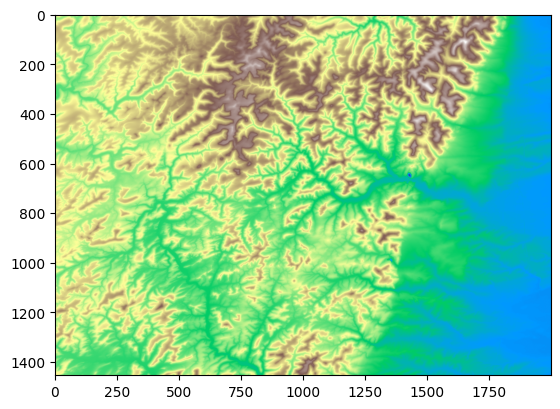

In [142]:
plt.imshow(cropped, cmap="terrain")

In [ ]:
with rasterio.open(dtm_crop_path) as src:
    data = src.read(1)
    # filled = fillnodata(data, mask=data==src.nodata)

(1454, 2000)


In [ ]:
grid = Grid.from_raster(str(dtm_crop_path))
dem = grid.read_raster(str(dtm_crop_path))

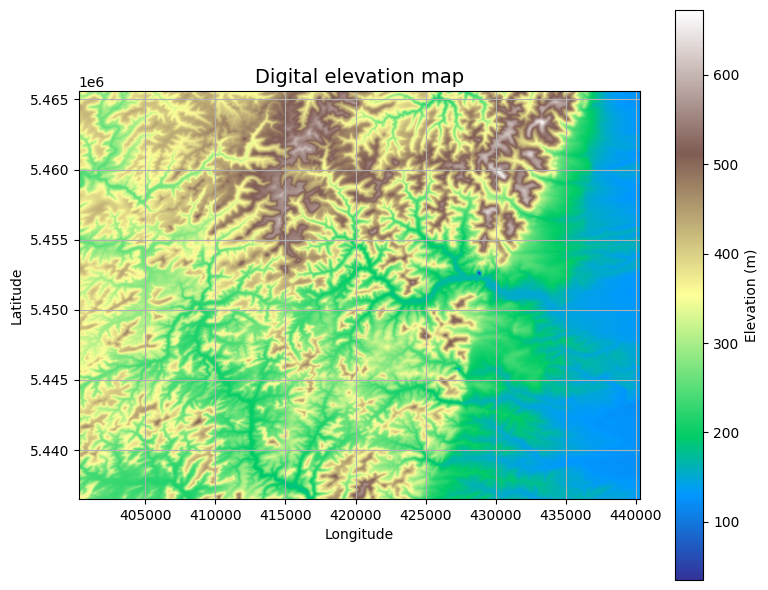

In [151]:
# Check DTM
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)

plt.imshow(dem, extent=grid.extent, cmap='terrain', zorder=1)
plt.colorbar(label='Elevation (m)')
plt.grid(zorder=0)
plt.title('Digital elevation map', size=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()

In [29]:
# --- Condition DEM ---

# Fill pits in DEM
pit_filled_dem = grid.fill_pits(dem)

# Fill depressions in DEM
flooded_dem = grid.fill_depressions(pit_filled_dem)
    
# Resolve flats in DEM
inflated_dem = grid.resolve_flats(flooded_dem)

AttributeError: 'numpy.ndarray' object has no attribute 'nodata'

### Open hyras precip files and crop ROI

In [ ]:
hyras_dir = data_root / "precip_hyras"
hyras_paths = [p for p in hyras_dir.rglob("*.nc")]

In [7]:
ds = xr.open_dataset(hyras_paths[0])

In [24]:
ds.coords

Coordinates:
  * time     (time) datetime64[ns] 3kB 1930-01-01T06:00:00 ... 1930-12-31T06:...
    lon      (y, x) float64 5MB ...
    lat      (y, x) float64 5MB ...
  * x        (x) float64 5kB 4.022e+06 4.022e+06 ... 4.684e+06 4.686e+06
  * y        (y) float64 7kB 2.674e+06 2.676e+06 ... 3.562e+06 3.564e+06

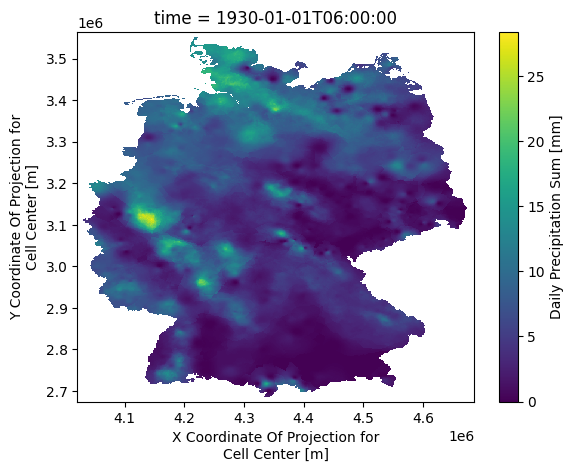

In [21]:
ds.pr.isel(time=0).plot()